In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import pandas as pd


In [7]:
# not set up yet
import wandb

super_secret_API_key = "d1678741bcd8eb1d90ca26aa8f2bf079256ac391"

wandb.login(key=super_secret_API_key)

WANDB_PROJECT = "ZNEUS_project2_cnn"
WANDB_ENTITY = None  # getpass.getuser()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\bizon\_netrc


In [8]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.randn(1).cuda())

print("CUDA available:", torch.cuda.is_available())


print("Current device index:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0))


2.9.1+cu130
13.0
tensor([0.3053], device='cuda:0')
CUDA available: True
Current device index: 0
Device name: NVIDIA GeForce RTX 3060 Laptop GPU


In [19]:
from dataclasses import dataclass, asdict


@dataclass
class Config:
    CSV_FILE: str = "images/sports.csv"
    ROOT_DIR: str = "images"
    BATCH_SIZE: int = 32
    NUM_EPOCHS: int = 500
    LEARNING_RATE: float = 0.001
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 3
    PIN_MEMORY: bool = True
    DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    PATIENCE: int = 150
    LR_SCHEDULER: str = "cosine"

In [20]:
from pathlib import Path

train_dir = Path("images/train")

# List all immediate subfolders in train (assuming each is a class)
class_folders = [f for f in train_dir.iterdir() if f.is_dir()]
num_classes = len(class_folders)

# Count all images across folders
image_count = 0
for folder in class_folders:
    img_files = list(folder.glob("*.jpg"))
    image_count += len(img_files)

print(f"Number of class folders: {num_classes}")
print(f"Total number of images: {image_count}")

Number of class folders: 100
Total number of images: 13492


In [21]:
import os
from pathlib import Path
from collections import Counter
from PIL import Image

train_dir = Path("images/train")
class_names = [f.name for f in train_dir.iterdir() if f.is_dir()]

# Count images per class
class_img_counts = {}
img_dims = Counter()

for class_name in class_names:
    class_path = train_dir / class_name
    img_files = list(class_path.glob("*.jpg"))
    class_img_counts[class_name] = len(img_files)
    # Optionally gather image shape stats
    for img_file in img_files:
        try:
            with Image.open(img_file) as img:
                img_dims[img.size] += 1  # img.size is (width, height)
        except Exception as e:
            print(f"Corrupted image: {img_file}")

print("Class image counts:")
for k, v in class_img_counts.items():
    print(f"{k}: {v}")

print("\nMost common image dimensions:")
for dim, count in img_dims.most_common(5):
    print(f"{dim}: {count}")

Class image counts:
air hockey: 112
ampute football: 112
archery: 132
arm wrestling: 99
axe throwing: 113
balance beam: 147
barell racing: 123
baseball: 174
basketball: 169
baton twirling: 108
bike polo: 110
billiards: 145
bmx: 140
bobsled: 138
bowling: 120
boxing: 116
bull riding: 149
bungee jumping: 125
canoe slamon: 164
cheerleading: 131
chuckwagon racing: 120
cricket: 129
croquet: 134
curling: 141
disc golf: 123
fencing: 135
field hockey: 157
figure skating men: 128
figure skating pairs: 151
figure skating women: 157
fly fishing: 134
football: 191
formula 1 racing: 190
frisbee: 131
gaga: 118
giant slalom: 150
golf: 157
hammer throw: 122
hang gliding: 121
harness racing: 147
high jump: 158
hockey: 172
horse jumping: 134
horse racing: 139
horseshoe pitching: 102
hurdles: 136
hydroplane racing: 108
ice climbing: 130
ice yachting: 112
jai alai: 132
javelin: 136
jousting: 118
judo: 150
lacrosse: 151
log rolling: 128
luge: 127
motorcycle racing: 132
mushing: 111
nascar racing: 189
olympi

In [12]:
non_jpg_files = {}

for class_folder in train_dir.iterdir():
    if class_folder.is_dir():
        files = [
            f
            for f in class_folder.iterdir()
            if f.is_file() and f.suffix.lower() != ".jpg"
        ]
        if files:
            non_jpg_files[class_folder.name] = [f.name for f in files]

if non_jpg_files:
    print("Non-JPG files found in the following folders:")
    for folder, files in non_jpg_files.items():
        print(f"{folder}: {files}")
else:
    print("All files are JPG images.")

All files are JPG images.


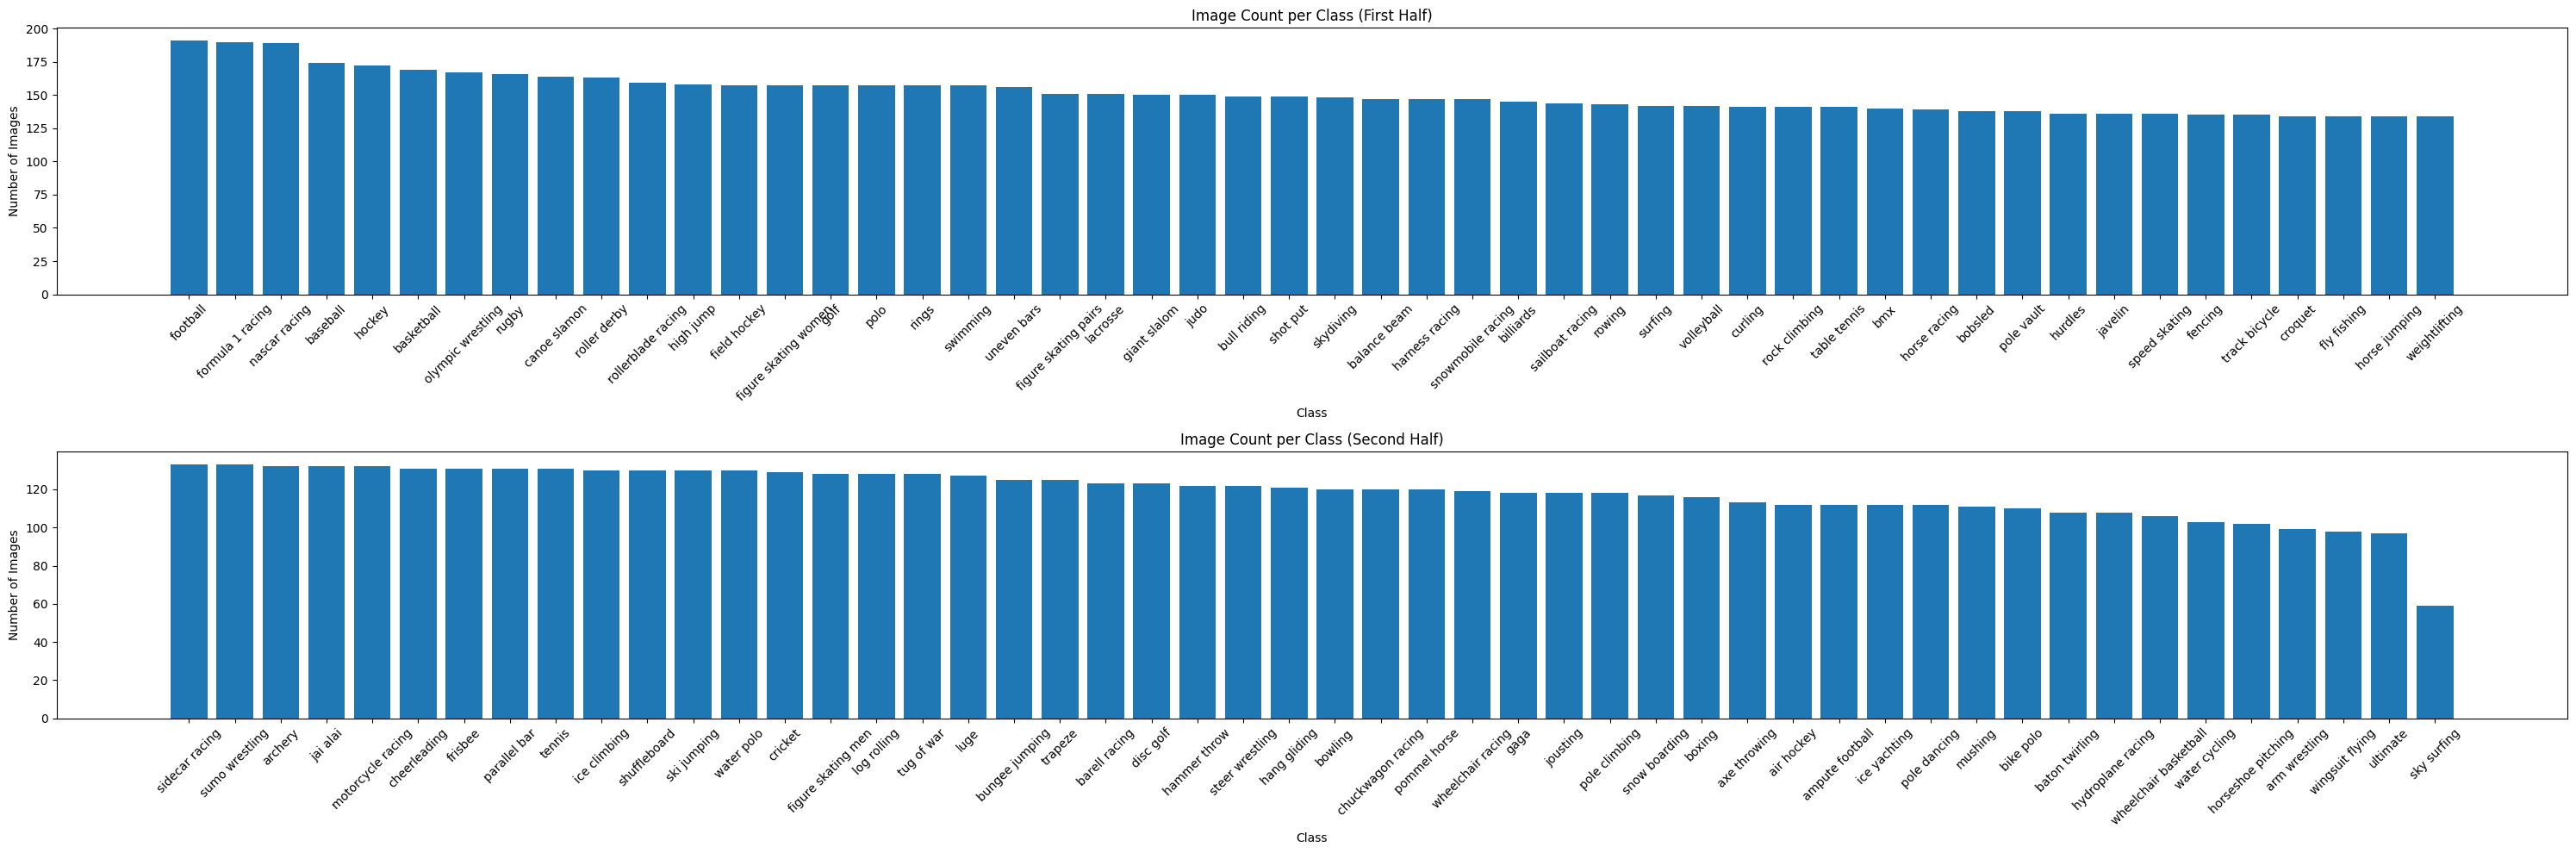

In [13]:
import matplotlib.pyplot as plt

classes = list(class_img_counts.keys())
counts = list(class_img_counts.values())

# Combine classes and counts into a list of tuples
class_count_pairs = sorted(zip(classes, counts), key=lambda x: x[1], reverse=True)

# Split the sorted pairs into two halves
midpoint = len(class_count_pairs) // 2
classes1, counts1 = (
    [pair[0] for pair in class_count_pairs[:midpoint]],
    [pair[1] for pair in class_count_pairs[:midpoint]],
)
classes2, counts2 = (
    [pair[0] for pair in class_count_pairs[midpoint:]],
    [pair[1] for pair in class_count_pairs[midpoint:]],
)

fig, axs = plt.subplots(2, 1, figsize=(30, 10))

axs[0].bar(classes1, counts1)
axs[0].set_title("Image Count per Class (First Half)")
axs[0].set_xlabel("Class")
axs[0].set_ylabel("Number of Images")
axs[0].set_xticks(range(len(classes1)))
axs[0].set_xticklabels(classes1, rotation=45)

axs[1].bar(classes2, counts2)
axs[1].set_title("Image Count per Class (Second Half)")
axs[1].set_xlabel("Class")
axs[1].set_ylabel("Number of Images")
axs[1].set_xticks(range(len(classes2)))
axs[1].set_xticklabels(classes2, rotation=45)

plt.tight_layout()
plt.show()

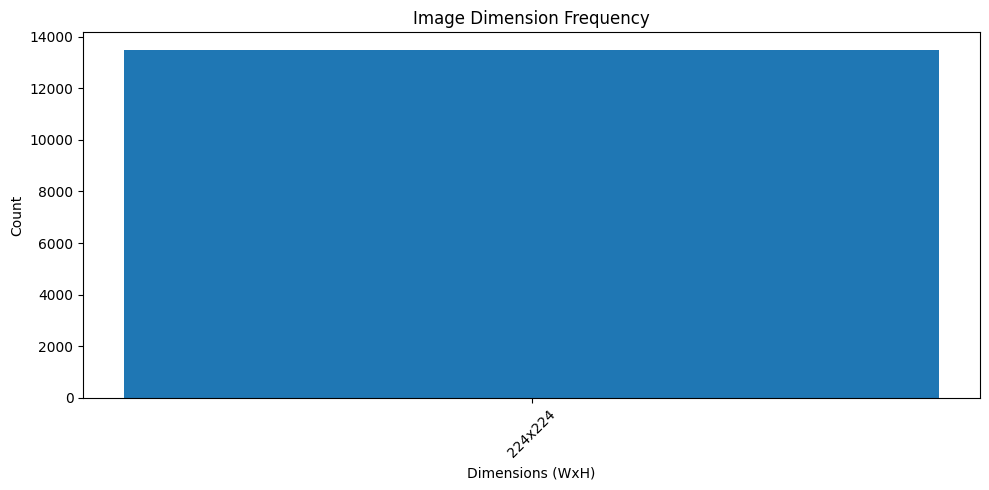

In [14]:
dims = [f"{w}x{h}" for (w, h) in img_dims.keys()]
counts_dim = list(img_dims.values())

plt.figure(figsize=(10, 5))
plt.bar(dims, counts_dim)
plt.title("Image Dimension Frequency")
plt.xlabel("Dimensions (WxH)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels):
        super(CustomCNN, self).__init__()
        # 1
        self.conv1 = nn.Conv2d(
            in_channels=in_channels, out_channels=32, kernel_size=(3, 3), padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 2
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=(3, 3), padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 3
        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=(3, 3), padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.25)

        self.lin1 = nn.Linear(128 * 4 * 4, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.5)
        self.lin2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.adaptive_pool(x)

        x = self.flatten(x)
        x = self.dropout1(x)

        x = self.lin1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout2(x)

        x = self.lin2(x)
        return x


def create_model(num_classes):
    model = CustomCNN(num_classes)
    return model

In [23]:
class SportsDataset(Dataset):
    def __init__(self, csv_file, root_dir, dataset_type, transform=None):
        df = pd.read_csv(csv_file)
        self.df = df[df["data set"] == dataset_type]
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(self.df["labels"].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["filepaths"])
        image = Image.open(img_path).convert("RGB")

        label = self.class_to_idx[row["labels"]]

        if self.transform:
            image = self.transform(image)

        return image, label


In [36]:
train_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.ToTensor(),  # <-- move this up
        # transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        # transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),  # now sees a tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


test_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
trainset = SportsDataset("images/sports.csv", "images", "train", train_transform)
validset = SportsDataset("images/sports.csv", "images", "valid", test_transform)
testset = SportsDataset("images/sports.csv", "images", "test", test_transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
validloader = DataLoader(validset, batch_size=32, shuffle=False)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

In [ ]:
# RGB intenzita
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def analyze_rgb_intensity(dataset, classes):
    """
    Analyze RGB intensity distribution across the dataset
    """
    rgb_means = {"R": [], "G": [], "B": []}

    print("Analyzing RGB intensities...")
    for idx in tqdm(range(len(dataset))):
        image, _ = dataset[idx]

        # If image is normalized, denormalize it first
        if image.min() < 0:  # Check if normalized
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = image * std + mean

        rgb_means["R"].append(image[0].mean().item())
        rgb_means["G"].append(image[1].mean().item())
        rgb_means["B"].append(image[2].mean().item())

    # Plot RGB distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ["red", "green", "blue"]
    channels = ["R", "G", "B"]

    for ax, color, channel in zip(axes, colors, channels):
        ax.hist(rgb_means[channel], bins=50, color=color, alpha=0.7, edgecolor="black")
        ax.set_xlabel(f"{channel} Intensity")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{channel} Channel Distribution")
        ax.axvline(
            np.mean(rgb_means[channel]),
            color="black",
            linestyle="--",
            label=f"Mean: {np.mean(rgb_means[channel]):.3f}",
        )
        ax.legend()

    plt.tight_layout()
    plt.savefig("rgb_intensity_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    return rgb_means


def compute_average_images_per_class(dataset, classes):
    """
    Compute and visualize average image for each class
    """
    # Initialize accumulators for each class
    class_sums = {cls: torch.zeros(3, 64, 64) for cls in classes}
    class_counts = {cls: 0 for cls in classes}

    print("Computing average images per class...")
    for idx in tqdm(range(len(dataset))):
        image, label = dataset[idx]
        class_name = classes[label]

        # Denormalize if needed
        if image.min() < 0:
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = image * std + mean

        class_sums[class_name] += image
        class_counts[class_name] += 1

    # Compute averages
    average_images = {}
    for cls in classes:
        average_images[cls] = class_sums[cls] / class_counts[cls]

    # Visualize average images
    num_classes = len(classes)
    cols = 5
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten() if num_classes > 1 else [axes]

    for idx, cls in enumerate(classes):
        avg_img = average_images[cls].permute(1, 2, 0).numpy()
        avg_img = np.clip(avg_img, 0, 1)  # Ensure values are in [0, 1]

        axes[idx].imshow(avg_img)
        axes[idx].set_title(f"{cls}\n(n={class_counts[cls]})", fontsize=10)
        axes[idx].axis("off")

    # Hide extra subplots
    for idx in range(num_classes, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.savefig("average_images_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()

    return average_images, class_counts


def plot_rgb_by_class(dataset, classes):
    """
    Plot RGB intensity distribution for each class
    """
    class_rgb = {cls: {"R": [], "G": [], "B": []} for cls in classes}

    print("Analyzing RGB by class...")
    for idx in tqdm(range(len(dataset))):
        image, label = dataset[idx]
        class_name = classes[label]

        # Denormalize if needed
        if image.min() < 0:
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = image * std + mean

        class_rgb[class_name]["R"].append(image[0].mean().item())
        class_rgb[class_name]["G"].append(image[1].mean().item())
        class_rgb[class_name]["B"].append(image[2].mean().item())

    # Plot
    num_classes = len(classes)
    cols = 3
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten() if num_classes > 1 else [axes]

    for idx, cls in enumerate(classes):
        ax = axes[idx]

        # Create histogram for each channel
        ax.hist(class_rgb[cls]["R"], bins=30, alpha=0.5, label="Red", color="red")
        ax.hist(class_rgb[cls]["G"], bins=30, alpha=0.5, label="Green", color="green")
        ax.hist(class_rgb[cls]["B"], bins=30, alpha=0.5, label="Blue", color="blue")

        ax.set_xlabel("Intensity")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{cls}")
        ax.legend()

    # Hide extra subplots
    for idx in range(num_classes, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.savefig("rgb_by_class.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Print statistics
    print("\nRGB Statistics by Class:")
    print("-" * 70)
    for cls in classes:
        r_mean = np.mean(class_rgb[cls]["R"])
        g_mean = np.mean(class_rgb[cls]["G"])
        b_mean = np.mean(class_rgb[cls]["B"])
        print(f"{cls:20} | R: {r_mean:.3f} | G: {g_mean:.3f} | B: {b_mean:.3f}")


# Usage:
# 1. RGB Intensity Distribution (overall)
rgb_stats = analyze_rgb_intensity(trainset, trainset.classes)

# 2. Average images per class
avg_images, counts = compute_average_images_per_class(trainset, trainset.classes)

# 3. RGB distribution by class
plot_rgb_by_class(trainset, trainset.classes)

In [37]:
config = Config()
model = CustomCNN(num_classes=len(trainset.classes), in_channels=3)
model = model.to(config.DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


In [38]:
def train(
    name,
    model,
    trainloader,
    validloader,
    testloader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=config.NUM_EPOCHS,
    patience=config.PATIENCE,
):
    # Initialize wandb
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=name,  # run name in W&B UI
        config={
            "epochs": epochs,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "architecture": model.__class__.__name__,
        },
    )

    # Watch model
    wandb.watch(model, criterion, log="all", log_freq=100)

    best_loss = float("inf")
    best_epoch = 0
    best_model_path = f"./models/{run.name}.pt"
    # os.makedirs("./model", exist_ok=True)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(trainloader.dataset)

        # ---- validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(validloader.dataset)

        # Scheduler step
        scheduler.step()

        # Test accuracy each epoch (optional, but you had it)
        test_accuracy = test(model, testloader, device)

        # Early stopping check
        if epoch - best_epoch >= patience:
            print("Early stopping at epoch", epoch)
            break

        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"  → Saved best model to {best_model_path}")

        # Log metrics to wandb
        wandb.log(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "learning_rate": optimizer.param_groups[0]["lr"],
                "test_accuracy": test_accuracy,
                "patience": (epoch - best_epoch),
            }
        )

        print(
            f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
        )

    print("Training finished!")

    # Load best model and log/save in W&B
    model.load_state_dict(torch.load(best_model_path))
    wandb.save(best_model_path)
    run.finish()

    return test_accuracy


def test(model, testloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy


# Then call it like this:
train(
    name="basic_cnn",
    model=model,
    testloader=testloader,
    trainloader=trainloader,
    validloader=validloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=config.DEVICE,
    epochs=config.NUM_EPOCHS,
)

epoch,▁▃▆█
learning_rate,█▆▄▁
patience,▁▃▆█
test_accuracy,▁▁█▄
train_loss,█▅▃▁
val_loss,▁█▂▃
epoch,3
learning_rate,0.00079
patience,3
test_accuracy,0.04
train_loss,3.02632


Test Accuracy: 0.2240
  → Saved best model to ./models/basic_cnn.pt
Epoch 0 | Train Loss: 4.0253 | Val Loss: 3.2442
Test Accuracy: 0.3100
  → Saved best model to ./models/basic_cnn.pt
Epoch 1 | Train Loss: 3.5351 | Val Loss: 2.8597
Test Accuracy: 0.3500
  → Saved best model to ./models/basic_cnn.pt
Epoch 2 | Train Loss: 3.2815 | Val Loss: 2.5885
Test Accuracy: 0.4220
  → Saved best model to ./models/basic_cnn.pt
Epoch 3 | Train Loss: 3.1223 | Val Loss: 2.3718
Test Accuracy: 0.4520
  → Saved best model to ./models/basic_cnn.pt
Epoch 4 | Train Loss: 2.9912 | Val Loss: 2.2609
Test Accuracy: 0.4240
  → Saved best model to ./models/basic_cnn.pt
Epoch 5 | Train Loss: 2.8898 | Val Loss: 2.1674
Test Accuracy: 0.4700
  → Saved best model to ./models/basic_cnn.pt
Epoch 6 | Train Loss: 2.7972 | Val Loss: 1.9742
Test Accuracy: 0.5220
  → Saved best model to ./models/basic_cnn.pt
Epoch 7 | Train Loss: 2.7005 | Val Loss: 1.9105
Test Accuracy: 0.5240
  → Saved best model to ./models/basic_cnn.pt
Epoc

KeyboardInterrupt: 

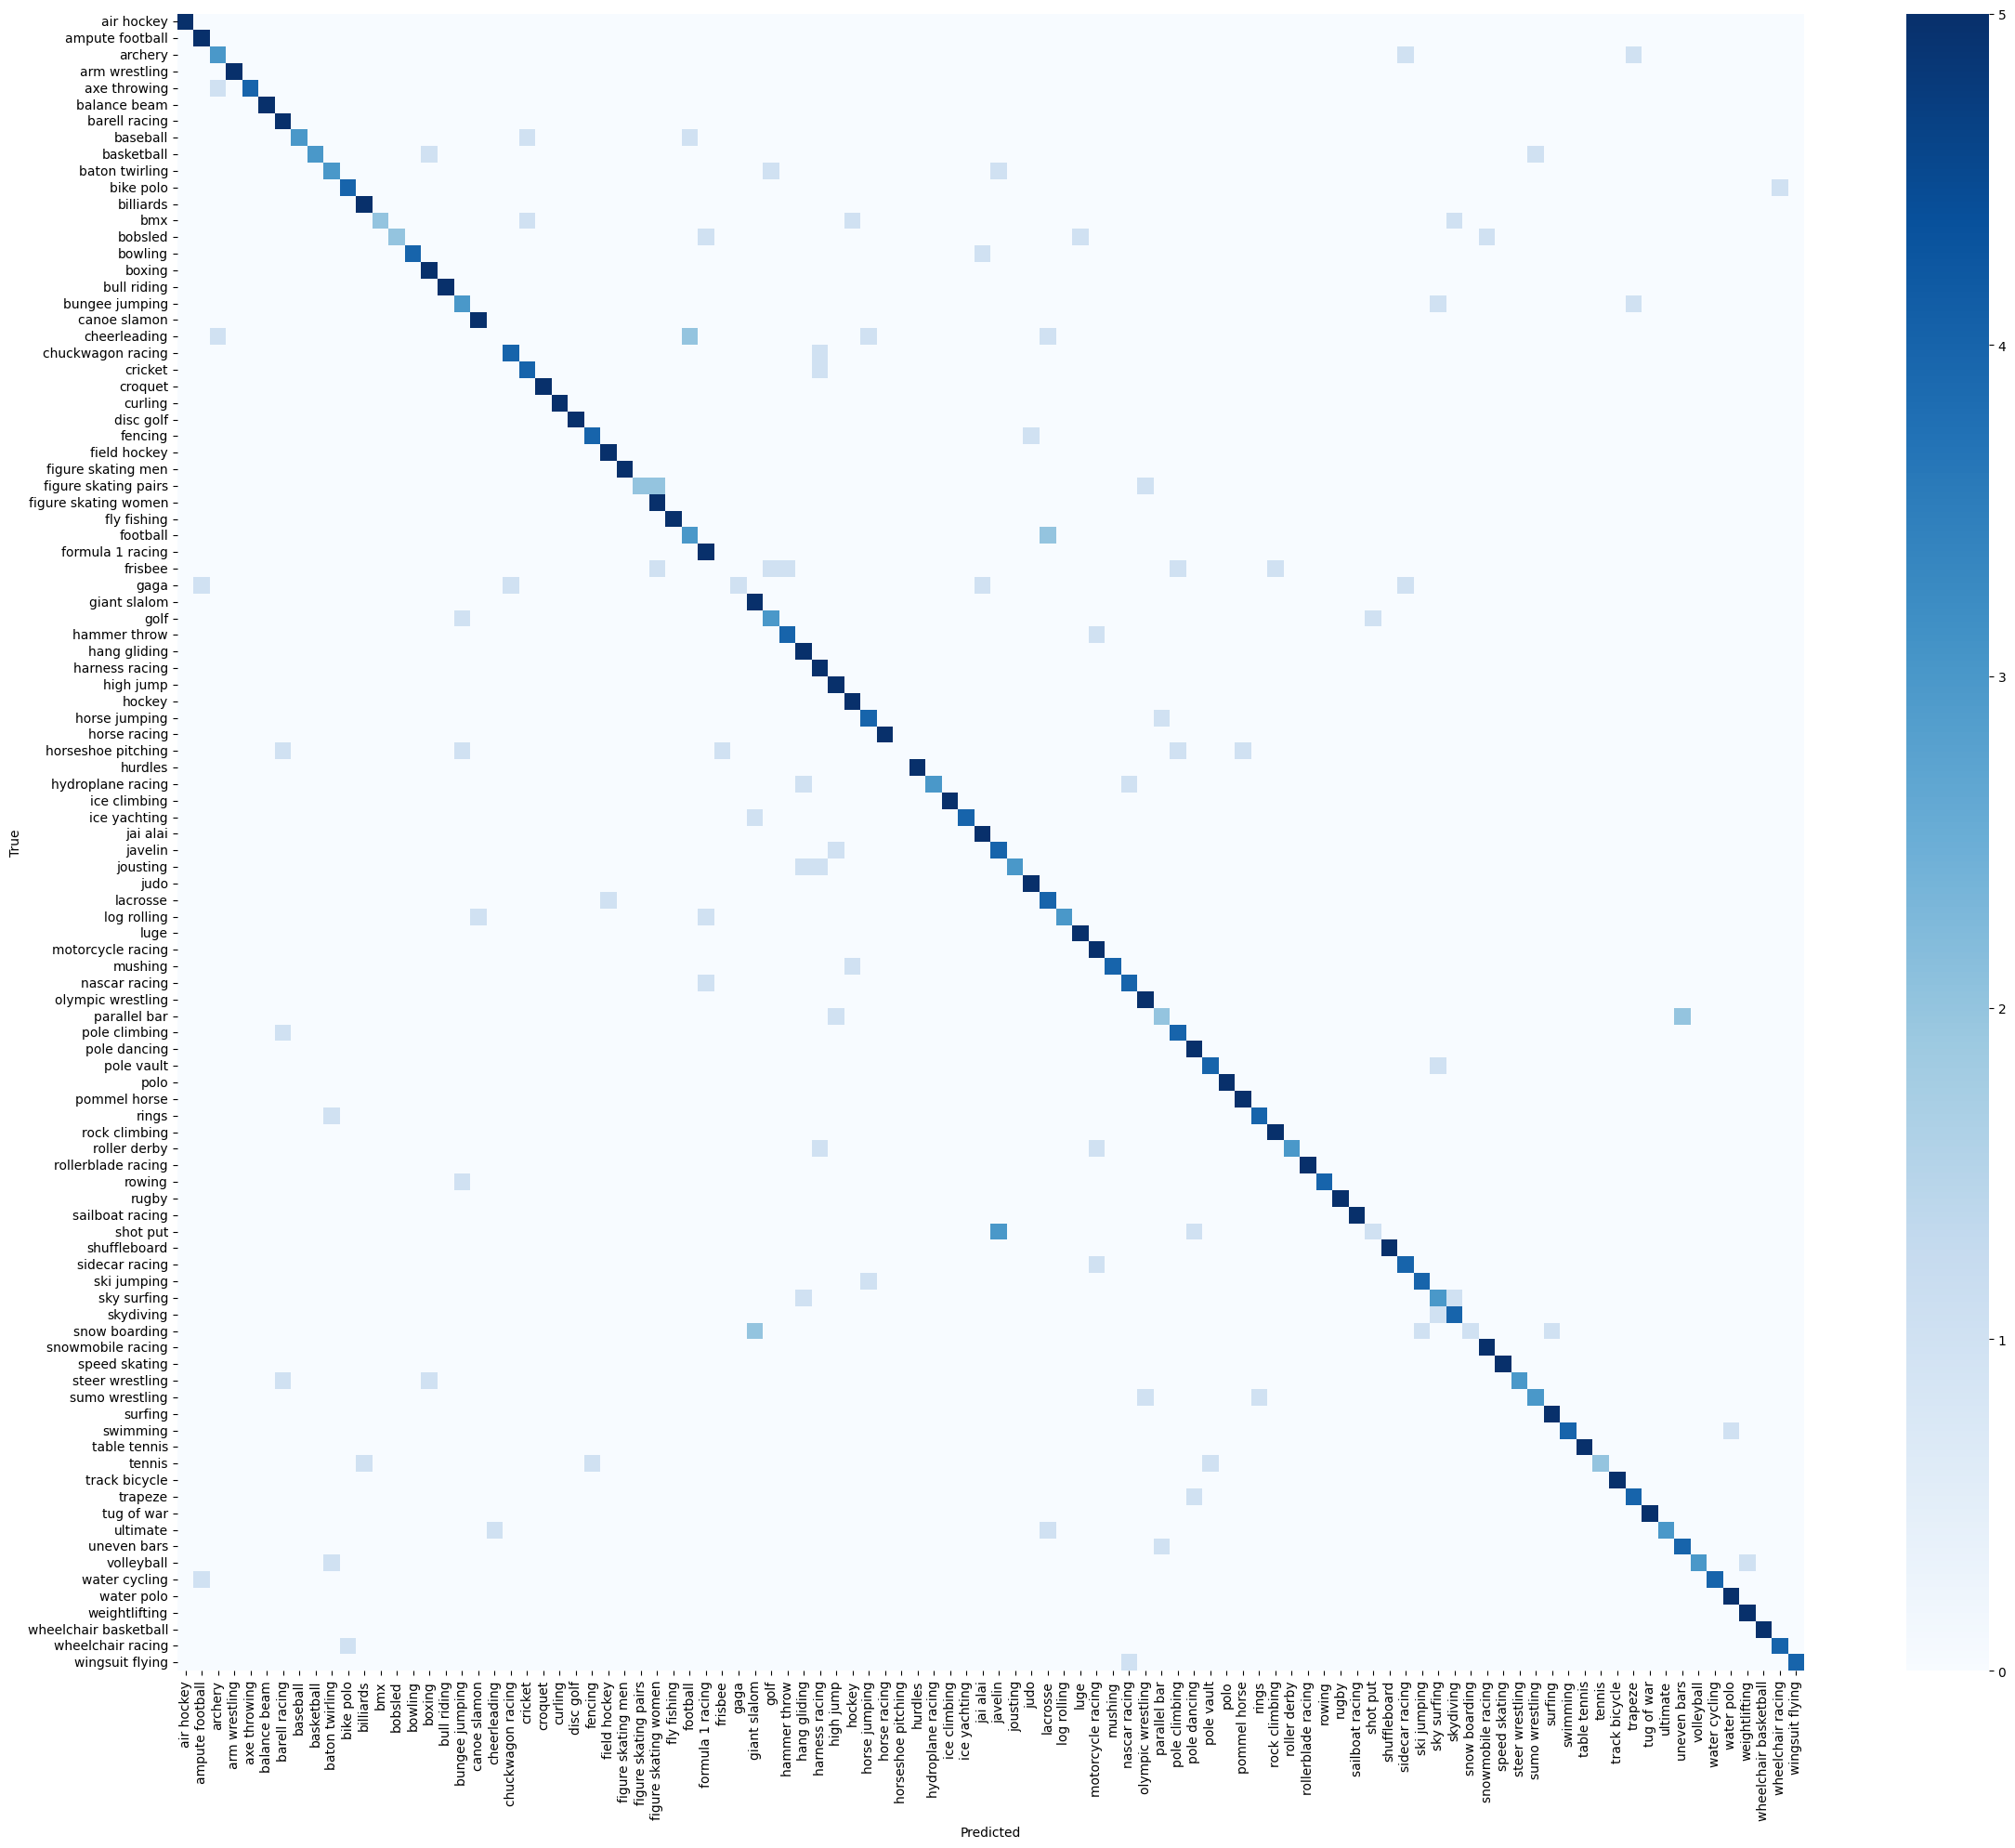

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


def plot_confusion(model, dataloader, classes, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    plt.figure(figsize=(24, 20))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return cm


cm = plot_confusion(model, testloader, trainset.classes, config.DEVICE)


In [46]:
train_acc = test(model, trainloader, config.DEVICE)
test_acc = test(model, testloader, config.DEVICE)
print("Train acc:", train_acc, "Test acc:", test_acc)


Test Accuracy: 0.8318
Test Accuracy: 0.8000
Train acc: 0.831826267417729 Test acc: 0.8


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)


def get_preds_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    return y_true, y_pred


y_true, y_pred = get_preds_labels(model, testloader, config.DEVICE)

# Overall accuracy
acc = accuracy_score(y_true, y_pred)

# Macro-averaged (treat all classes equally)
prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

# Weighted-averaged (accounts for class imbalance)
prec_weight = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_weight = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", acc)
print("Macro Precision:", prec_macro)
print("Macro Recall:", rec_macro)
print("Macro F1:", f1_macro)
print("Weighted Precision:", prec_weight)
print("Weighted Recall:", rec_weight)
print("Weighted F1:", f1_weight)


print(
    classification_report(
        y_true, y_pred, target_names=trainset.classes, zero_division=0
    )
)


Accuracy: 0.8
Macro Precision: 0.8125555555555555
Macro Recall: 0.8
Macro F1: 0.7825863580863579
Weighted Precision: 0.8125555555555557
Weighted Recall: 0.8
Weighted F1: 0.7825863580863581
                       precision    recall  f1-score   support

           air hockey       1.00      1.00      1.00         5
      ampute football       0.71      1.00      0.83         5
              archery       0.60      0.60      0.60         5
        arm wrestling       1.00      1.00      1.00         5
         axe throwing       1.00      0.80      0.89         5
         balance beam       1.00      1.00      1.00         5
        barell racing       0.62      1.00      0.77         5
             baseball       1.00      0.60      0.75         5
           basketball       1.00      0.60      0.75         5
       baton twirling       0.60      0.60      0.60         5
            bike polo       0.80      0.80      0.80         5
            billiards       0.83      1.00      0.91  

Accuracy: 0.8
Macro Precision: 0.8125555555555555
Macro Recall: 0.8
Macro F1: 0.7825863580863579


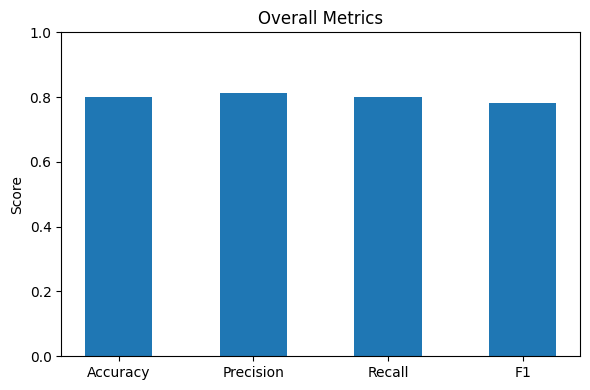

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Global (macro) metrics
acc = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("Accuracy:", acc)
print("Macro Precision:", prec_macro)
print("Macro Recall:", rec_macro)
print("Macro F1:", f1_macro)

# Bar plot for the totals
metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [acc, prec_macro, rec_macro, f1_macro]

x = np.arange(len(metrics))

plt.figure(figsize=(6, 4))
plt.bar(x, values, width=0.5)
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Overall Metrics")
plt.tight_layout()
plt.show()
